# Analyse exploratoire d'un essai clinique

## Objectif

Cette analyse vise à explorer les données d'un essai clinique comparant un placebo et trois traitements (A, B et C).

Les principaux objectifs sont :
- décrire la population étudiée ;
- explorer la répartition des traitements ;
- analyser l'évolution du biomarqueur entre J0 et J28 ;
- comparer les réponses selon le traitement ;
- explorer les effets indésirables et leur relation avec la dose ;
- vérifier la comparabilité des groupes à l'inclusion.

In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/essai_clinique_clean.csv", sep=";")

In [2]:
df.shape

(180, 13)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   N° Patient         180 non-null    str    
 1   Centre             180 non-null    str    
 2   Sexe               180 non-null    str    
 3   Age (ans)          179 non-null    float64
 4   Poids (kg)         180 non-null    float64
 5   Traitement         180 non-null    str    
 6   Dose (mg)          176 non-null    float64
 7   Duree traitement   180 non-null    int64  
 8   Biomarqueur J0     180 non-null    float64
 9   Biomarqueur J28    177 non-null    float64
 10  Effet indesirable  173 non-null    str    
 11  Reponse            180 non-null    str    
 12  Date visite        180 non-null    str    
dtypes: float64(5), int64(1), str(7)
memory usage: 18.4 KB


In [4]:
df.head()

,N° Patient,Centre,Sexe,Age (ans),Poids (kg),Traitement,Dose (mg),Duree traitement,Biomarqueur J0,Biomarqueur J28,Effet indesirable,Reponse,Date visite
0,PAT-0110,CH Lyon Sud,H,38.0,68.5,TRAITEMENT B,98.0,26,114.7,84.8,Non,Répondeur,2026-06-29
1,PAT-0103,CHU Nice,H,52.0,60.1,TRAITEMENT C,142.0,26,106.8,65.6,Oui,Répondeur,2026-01-30
2,PAT-0052,CHU Nice,H,33.0,72.1,TRAITEMENT B,100.0,37,102.7,88.5,Non,Répondeur,2026-04-13
3,PAT-0080,CHU Marseille,F,55.0,72.7,TRAITEMENT B,100.0,27,76.2,66.2,Non,Répondeur,2026-05-12
4,PAT-0155,CHU Nice,H,35.0,72.3,TRAITEMENT A,52.0,24,107.4,98.3,Non,Répondeur,2026-07-13


## 1. Exploration de la population

Cette première étape permet de décrire les principales caractéristiques des patients, notamment l'âge et le poids.

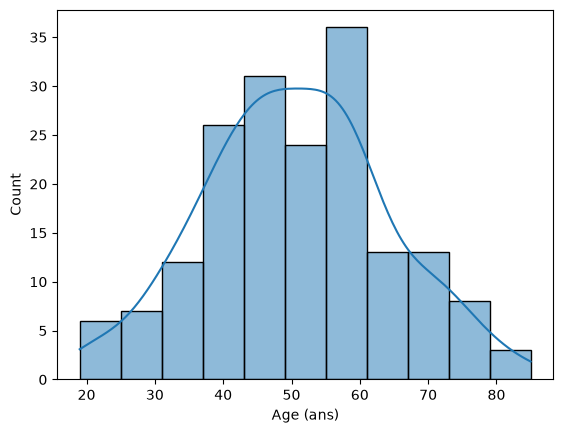

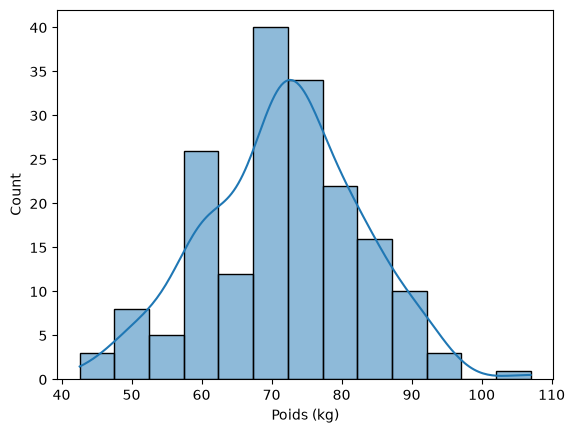

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(data=df, x="Age (ans)", kde=True)
plt.savefig("../figures/distribution_age.png", dpi=300, bbox_inches="tight")
plt.show()
sns.histplot(data=df, x="Poids (kg)", kde=True)
plt.savefig("../figures/distribution_poids.png", dpi=300, bbox_inches="tight")
plt.show()


## 2. Répartition des traitements

La répartition des patients entre le placebo et les trois traitements est examinée afin de vérifier la composition de la population étudiée.

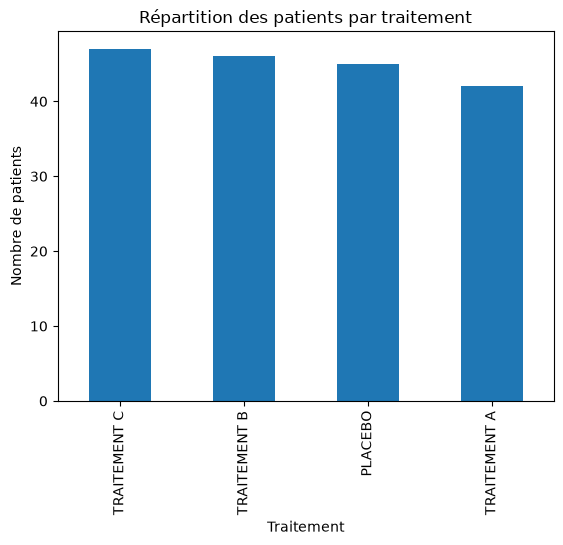

In [29]:
df["Traitement"].value_counts().plot(kind="bar")
plt.title("Répartition des patients par traitement")
plt.xlabel("Traitement")
plt.ylabel("Nombre de patients")
plt.savefig("../figures/répartition_des_patients_par_traitement.png", dpi=300, bbox_inches="tight")
plt.show()

## 3. Évolution du biomarqueur

La variation du biomarqueur est calculée comme la différence entre sa valeur à J28 et sa valeur à J0.

Une valeur négative correspond à une diminution du biomarqueur entre J0 et J28.

In [30]:
df["Traitement"].value_counts()
df["biomarker_change"]=df["Biomarqueur J28"]-df["Biomarqueur J0"]

In [6]:
df[["Biomarqueur J0", "Biomarqueur J28", "biomarker_change"]].head()

,Biomarqueur J0,Biomarqueur J28,biomarker_change
0,114.7,84.8,-29.9
1,106.8,65.6,-41.2
2,102.7,88.5,-14.2
3,76.2,66.2,-10.0
4,107.4,98.3,-9.1


In [7]:
df[["Biomarqueur J0", "Biomarqueur J28", "biomarker_change"]].describe()

,Biomarqueur J0,Biomarqueur J28,biomarker_change
count,180.000000,177.000000,177.000000
mean,100.686667,87.087571,-13.562712
std,17.203655,20.074658,9.895722
min,54.100000,33.100000,-41.200000
25%,90.300000,73.700000,-20.100000
50%,101.300000,88.400000,-13.400000
75%,112.700000,100.200000,-6.600000
max,143.400000,135.700000,7.600000


In [8]:
df.groupby("Traitement")["biomarker_change"].mean()

Traitement
PLACEBO         -5.104651
TRAITEMENT A    -9.333333
TRAITEMENT B   -16.095652
TRAITEMENT C   -22.797826
Name: biomarker_change, dtype: float64

### Variation du biomarqueur selon le traitement

La distribution de la variation du biomarqueur est comparée entre les différents groupes de traitement.

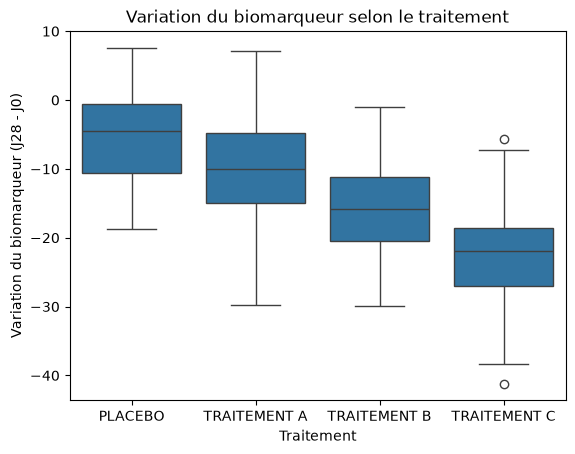

In [40]:
ordre_traitements = ["PLACEBO", "TRAITEMENT A", "TRAITEMENT B", "TRAITEMENT C"]
sns.boxplot(data=df, x="Traitement", y="biomarker_change", order=ordre_traitements)

plt.title("Variation du biomarqueur selon le traitement")
plt.xlabel("Traitement")
plt.ylabel("Variation du biomarqueur (J28 - J0)")

plt.savefig("../figures/variation_du_biomarqueur_selon_traitement.png", dpi=300, bbox_inches="tight")
plt.show()

In [10]:
df.groupby("Traitement")["Reponse"].value_counts()
pd.crosstab(df["Traitement"], df["Reponse"], normalize="index") * 100

Reponse,Non répondeur,Répondeur
Traitement,,
PLACEBO,60.000000,40.000000
TRAITEMENT A,45.238095,54.761905
TRAITEMENT B,21.739130,78.260870
TRAITEMENT C,10.638298,89.361702


## 4. Réponse au traitement

La proportion de patients répondeurs est comparée entre les différents groupes de traitement.

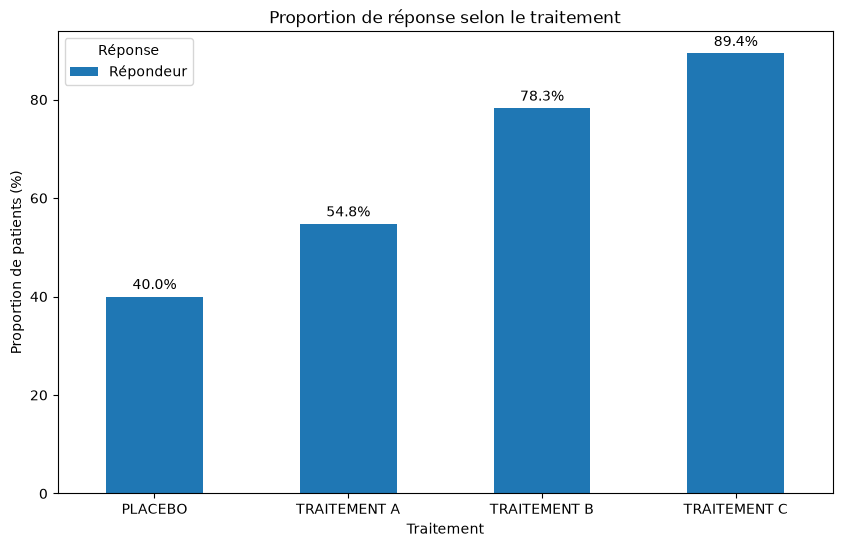

In [48]:
ordre_traitements = ["PLACEBO", "TRAITEMENT A", "TRAITEMENT B", "TRAITEMENT C"]
proportions = (
    pd.crosstab(df["Traitement"], df["Reponse"], normalize="index") * 100
).reindex(ordre_traitements)
proportions=proportions["Répondeur"]
ax=proportions.plot(
    kind="bar",
    stacked=False,
    figsize=(10, 6)
)
plt.title("Proportion de réponse selon le traitement")
plt.xlabel("Traitement")
plt.ylabel("Proportion de patients (%)")
plt.xticks(rotation=0)
plt.legend(title="Réponse")
plt.savefig(
    "../figures/proportion_reponse_selon_traitement.png",
    dpi=300,
    bbox_inches="tight"
)
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.savefig(
    "../figures/proportion_reponse_selon_traitement.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 5. Tolérance et effets indésirables

La fréquence des effets indésirables est examinée selon le traitement.

La relation entre la dose administrée et la présence d'un effet indésirable est également étudiée.

In [13]:
df["Effet indesirable"].value_counts()
pd.crosstab(
    df["Traitement"],
    df["Effet indesirable"],
    normalize="index"
) * 100

Effet indesirable,Non,Oui
Traitement,,
PLACEBO,90.909091,9.090909
TRAITEMENT A,92.857143,7.142857
TRAITEMENT B,76.744186,23.255814
TRAITEMENT C,65.909091,34.090909


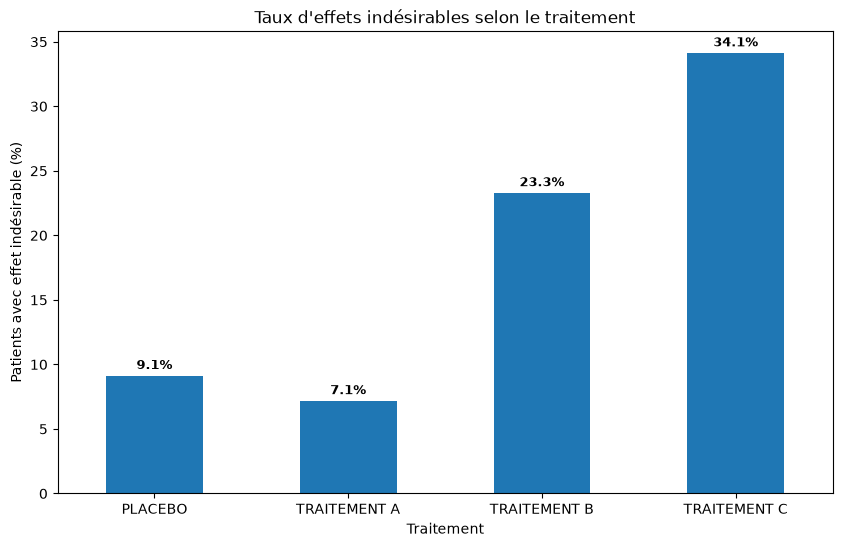

In [50]:
taux_effets_indesirables = (
    pd.crosstab(
        df["Traitement"],
        df["Effet indesirable"],
        normalize="index"
    ) * 100
).reindex(ordre_traitements)

taux_effets_indesirables = taux_effets_indesirables["Oui"]

ax = taux_effets_indesirables.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Taux d'effets indésirables selon le traitement")
plt.xlabel("Traitement")
plt.ylabel("Patients avec effet indésirable (%)")
plt.xticks(rotation=0)

ax.bar_label(
    ax.containers[0],
    fmt="%.1f%%",
    padding=3,
    fontsize=9,
    fontweight="bold"
)

plt.savefig(
    "../figures/taux_effets_indesirables_selon_traitement.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 6. Comparabilité des groupes à l'inclusion

Avant d'interpréter les différences entre traitements, les groupes sont comparés à l'inclusion sur plusieurs caractéristiques : âge, sexe et biomarqueur J0.

### Comparaison de la dose selon la survenue d'effets indésirables

Le test de Mann-Whitney est utilisé pour comparer la **dose administrée** entre les patients ayant présenté un effet indésirable et ceux n’en ayant pas présenté.

* **H₀** : la distribution de la dose est similaire entre les deux groupes.
* **H₁** : la distribution de la dose diffère entre les deux groupes.

Un seuil de significativité de **5 % (α = 0,05)** est retenu.


In [15]:
from scipy.stats import mannwhitneyu

dose_oui = df.loc[df["Effet indesirable"] == "Oui", "Dose (mg)"].dropna()
dose_non = df.loc[df["Effet indesirable"] == "Non", "Dose (mg)"].dropna()

stat, p = mannwhitneyu(dose_oui, dose_non)

print("Statistique U :", stat)
print("p-value :", p)

Statistique U : 2921.0
p-value : 0.0014887572031818926


### Test de Kruskal-Wallis : variation du biomarqueur selon le centre

Le test de Kruskal-Wallis est utilisé pour comparer la **variation du biomarqueur (J28 − J0)** entre plusieurs centres indépendants.

Cette analyse permet de déterminer si la distribution de la variation du biomarqueur diffère significativement selon le centre.

* **H₀** : les distributions de la variation du biomarqueur sont similaires entre les centres.
* **H₁** : au moins un centre présente une distribution différente.

Un seuil de significativité de **5 % (α = 0,05)** est retenu.


In [16]:
from scipy.stats import kruskal

groupes_centre = [
    groupe["biomarker_change"].dropna()
    for _, groupe in df.groupby("Centre")
]

stat, p = kruskal(*groupes_centre)

print("Statistique H :", stat)
print("p-value :", p)

Statistique H : 2.4409174900116173
p-value : 0.2950947626197725


### Test du Chi² : association entre le centre et le groupe

Le test du Chi² d’indépendance est utilisé pour déterminer s’il existe une association statistiquement significative entre le **centre** et le **groupe de traitement**.

Les deux variables étant catégorielles, ce test permet de vérifier si la répartition des groupes de traitement diffère selon les centres.

* **H₀** : le centre et le groupe de traitement sont indépendants.
* **H₁** : le centre et le groupe de traitement sont associés.

Un seuil de significativité de **5 % (α = 0,05)** est retenu.


In [51]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df["Centre"], df["Traitement"])

chi2, p, ddl, effectifs_attendus = chi2_contingency(table)

print("Statistique du Chi² :", chi2)
print("Degrés de liberté :", ddl)
print("p-value :", p)

Statistique du Chi² : 4.674170432807767
Degrés de liberté : 6
p-value : 0.5862289857001843


### Test du Chi² : association entre le traitement et la réponse

Le test du Chi² d’indépendance est utilisé pour déterminer s’il existe une association entre le **groupe de traitement** et la **réponse au traitement**.

* **H₀** : le traitement et la réponse sont indépendants.
* **H₁** : le traitement et la réponse sont associés.

Un seuil de significativité de **5 % (α = 0,05)** est retenu.


In [12]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df["Traitement"], df["Reponse"])

chi2, p, ddl, expected = chi2_contingency(table)

print("Chi² :", chi2)
print("p-value :", p)
print("ddl :", ddl)

Chi² : 30.480030231106408
p-value : 1.0937014054090277e-06
ddl : 3


In [17]:
from scipy.stats import kruskal

groupes_age = [
    groupe["Age (ans)"].dropna()
    for _, groupe in df.groupby("Traitement")
]

stat, p = kruskal(*groupes_age)

print("Statistique H :", stat)
print("p-value :", p)

Statistique H : 3.2253530339180667
p-value : 0.35816796740358675


In [18]:
from scipy.stats import chi2_contingency

table_sexe = pd.crosstab(df["Traitement"], df["Sexe"])

chi2, p, ddl, expected = chi2_contingency(table_sexe)

print("Chi² :", chi2)
print("p-value :", p)
print("ddl :", ddl)

Chi² : 0.9525205780739687
p-value : 0.8127383764355846
ddl : 3


In [25]:
groupes_j0 = [
    groupe["Biomarqueur J0"].dropna()
    for _, groupe in df.groupby("Traitement")
]

stat, p = kruskal(*groupes_j0)

print("Statistique H :", stat)
print("p-value :", p)

Statistique H : 0.8983754561152841
p-value : 0.8258198311277886


In [26]:
groupes_j0 = [
    groupe["Biomarqueur J0"].dropna()
    for _, groupe in df.groupby("Traitement")
]

stat, p = kruskal(*groupes_j0)

print("Statistique H :", stat)
print("p-value :", p)

Statistique H : 0.8983754561152841
p-value : 0.8258198311277886


## 7. Conclusion

L'analyse exploratoire permet de décrire la population, la répartition des traitements, l'évolution du biomarqueur, la réponse au traitement et le profil de tolérance.

Les résultats statistiques détaillés sont présentés dans le rapport d'analyse associé.